In [127]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB


In [128]:
data_fake=pd.read_csv("D:/ML_PROJECT/Fake.csv")
data_true=pd.read_csv("D:/ML_PROJECT/True.csv")

In [129]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [130]:
data_true.tail()

,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [131]:
data_fake["class"]=0
data_true['class']=1

In [132]:
data = pd.concat([data_fake, data_true], axis=0)
data = data.sample(frac=1)  # Randomly shuffle the dataframe


In [133]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
class      0
dtype: int64

<Axes: xlabel='class', ylabel='count'>

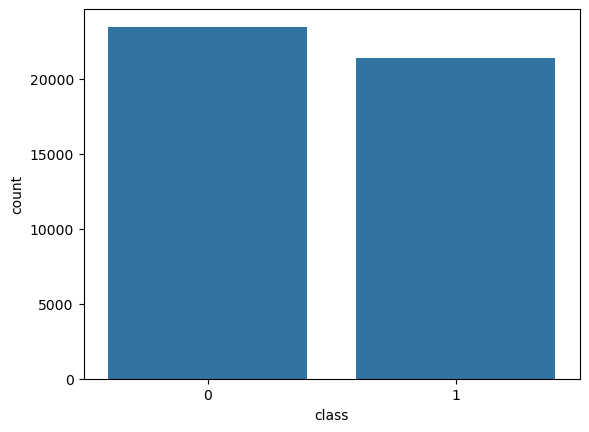

In [134]:
import seaborn as sns
sns.countplot(x = 'class',data = data)

In [135]:
data.shape

(44898, 5)

In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 2241 to 17899
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   class    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [137]:
data.describe()

,class
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [138]:
def wordopt(text):
    text = text.lower()
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

In [139]:
data['text'] = data['text'].apply(wordopt)

In [140]:
x = data['text']
y = data['class']

In [141]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)


In [142]:

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("Y_train shape:", y_train.shape)
print("Y_test shape:", y_test.shape)

X_train shape: (33673,)
X_test shape: (11225,)
Y_train shape: (33673,)
Y_test shape: (11225,)


In [143]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Convert text to vectors
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [144]:
LR = LogisticRegression()
LR.fit(xv_train, y_train)

LogisticRegression()

In [145]:
pred_lr = LR.predict(xv_test)
print("Logistic Regression:\n")
print("Classification Report:\n:", classification_report(y_test, pred_lr))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_lr))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_lr))


Logistic Regression:

Classification Report:
:               precision    recall  f1-score   support

           0       0.99      0.98      0.99      5866
           1       0.98      0.99      0.99      5359

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225


Confusion matrix:
 [[5777   89]
 [  51 5308]]

Accuracy Score:
 0.9875278396436525


In [146]:
DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [147]:
pred_dt = DT.predict(xv_test)
print("Decision Tree:\n")
print("Classification Report:\n:", classification_report(y_test, pred_dt))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_dt))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_dt))

Decision Tree:

Classification Report:
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5866
           1       1.00      1.00      1.00      5359

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225


Confusion matrix:
 [[5841   25]
 [  20 5339]]

Accuracy Score:
 0.9959910913140312


In [148]:
RF = RandomForestClassifier(random_state=0)
RF.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [149]:
pred_rf = RF.predict(xv_test)
print("Random Forest:\n")
print("Classification Report:\n:", classification_report(y_test, pred_rf))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_rf))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_rf))


Random Forest:

Classification Report:
:               precision    recall  f1-score   support

           0       0.99      0.99      0.99      5866
           1       0.99      0.99      0.99      5359

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225


Confusion matrix:
 [[5815   51]
 [  57 5302]]

Accuracy Score:
 0.9903786191536749


In [150]:
KNN = KNeighborsClassifier()
KNN.fit(xv_train, y_train)

KNeighborsClassifier()

In [151]:
pred_knn = KNN.predict(xv_test)
print("K Nearest Neighbours:\n")
print("Classification Report:\n:", classification_report(y_test, pred_knn))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_knn))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_knn))

K Nearest Neighbours:

Classification Report:
:               precision    recall  f1-score   support

           0       0.63      0.98      0.77      5866
           1       0.94      0.37      0.53      5359

    accuracy                           0.69     11225
   macro avg       0.79      0.68      0.65     11225
weighted avg       0.78      0.69      0.66     11225


Confusion matrix:
 [[5740  126]
 [3366 1993]]

Accuracy Score:
 0.6889086859688196


In [152]:
MNB = MultinomialNB()
MNB.fit(xv_train, y_train)

MultinomialNB()

In [153]:
pred_mnb = MNB.predict(xv_test)
print("Multinomial Naive Bayes:\n")
print("Classification Report:\n:", classification_report(y_test, pred_mnb))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_mnb))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_mnb))

Multinomial Naive Bayes:

Classification Report:
:               precision    recall  f1-score   support

           0       0.93      0.95      0.94      5866
           1       0.94      0.93      0.93      5359

    accuracy                           0.94     11225
   macro avg       0.94      0.94      0.94     11225
weighted avg       0.94      0.94      0.94     11225


Confusion matrix:
 [[5562  304]
 [ 401 4958]]

Accuracy Score:
 0.9371937639198218


In [154]:
BNB = BernoulliNB()
BNB.fit(xv_train, y_train)

BernoulliNB()

In [155]:
pred_bnb = BNB.predict(xv_test)
print("Bernoulli Naive Bayes:\n")
print("Classification Report:\n:", classification_report(y_test, pred_bnb))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_bnb))
print("\nAccuracy Score:\n", accuracy_score(y_test, pred_bnb))

Bernoulli Naive Bayes:

Classification Report:
:               precision    recall  f1-score   support

           0       0.96      0.92      0.94      5866
           1       0.91      0.96      0.94      5359

    accuracy                           0.94     11225
   macro avg       0.94      0.94      0.94     11225
weighted avg       0.94      0.94      0.94     11225


Confusion matrix:
 [[5384  482]
 [ 217 5142]]

Accuracy Score:
 0.937728285077951


In [156]:
def output_label(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

In [157]:
def manual_testing(news):
    testing_news = {"text": [news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test['text'] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_RF = RF.predict(new_xv_test)
    pred_knn = KNN.predict(new_xv_test)
    pred_mnb = MNB.predict(new_xv_test)
    pred_bnb = BNB.predict(new_xv_test)
    print("\n\nLR Prediction: {} \nDT Prediction: {} \nRF Prediction: {}  \nKNN Prediction: {} \nMNB Prediction: {} \nBNB Prediction: {}".format(
        output_label(pred_LR[0]),
        output_label(pred_DT[0]),
        output_label(pred_RF[0]),
        output_label(pred_knn[0]),
        output_label(pred_mnb[0]),
        output_label(pred_bnb[0]),
    ))

In [194]:
news = str(input("Enter news text for prediction: ")) 
manual_testing(news)

Enter news text for prediction:  As U.S. budget fight looms, Republicans flip their fiscal script




LR Prediction: Fake News 
DT Prediction: Fake News 
RF Prediction: Fake News  
KNN Prediction: Fake News 
MNB Prediction: Fake News 
BNB Prediction: Not A Fake News
